In [1]:
from tripodpy import Simulation
import numpy as np 
import csv
import matplotlib.pyplot as plt
import dustpy.constants as c

In [2]:
from scipy.interpolate import interp1d
import dustpy
from dustpy import constants as c
from dustpy.utils import Boundary
from dustpylib.substructures.gaps.gaps import duffell2020

amu = 1.66053886e-24

au = dustpy.constants.au
year = dustpy.constants.year




##########################################################################
# Simulation with Mstar = 1 Msun
##########################################################################

sim = Simulation()

# Grid Configuration
ri = np.geomspace(2.0, 250, 400) * c.au
sim.grid.ri = ri
#sim.ini.grid.Nmbpd = 7
sim.ini.grid.mmin = (4./3.*np.pi*1.67*1e-5**3)

# Gas Parameters
sim.ini.gas.alpha = 0.001
sim.ini.gas.SigmaRc = 60.0 * au
sim.ini.gas.SigmaExp = -0.85
sim.ini.gas.mu = 2.33*amu

# Dust Parameters
sim.ini.dust.vFrag = 1000.0
sim.ini.dust.d2gRatio = 0.01
sim.ini.dust.allowDriftingParticles = False


sim.ini.gas.Mdisk = 0.05*sim.ini.star.M

sim.initialize()


#sim.t.snapshots = sim.t.snapshots[sim.t.snapshots < 1e5*year]

# Turn off gas evolution
sim.gas.nu[:] = 0.0
sim.gas.nu.updater = None


a_p =  5.2*au
q_p = 1e-3
f_h = interp1d(sim.grid.r, sim.gas.Hp/sim.grid.r)
h = f_h(a_p)
alpha_mod = duffell2020(sim.grid.r, a_p, q_p, h, sim.ini.gas.alpha)
sim.gas.Sigma[...]  *= alpha_mod
sim.components.Default.gas.Sigma[...]  *=alpha_mod
sim.dust.Sigma[...] *= (alpha_mod)[:, None]


sim.gas.rho.update()
sim.gas.P.update()

sim.dust.s.boundary.inner = Boundary(
            sim.grid.r,
            sim.grid.ri,
            sim.dust.Sigma[...,1]*sim.dust.s.max,
            condition="const_pow")

sim.dust.s.boundary.outer = Boundary(
            sim.grid.r,
            sim.grid.ri,
            sim.dust.Sigma[...,1]*sim.dust.s.max,
            condition="const_pow")


sim.update()


sim.writer.datadir = "data_duffle"
sim.writer.overwrite = True

In [3]:

with open("gap_test_sim.csv", "w", newline="") as f:
    writer = csv.writer(f)


    for row in zip(sim.grid.r,sim.grid.OmegaK,sim.gas.Sigma,sim.gas.cs,sim.gas.Hp,sim.gas.T,sim.gas.mu,sim.gas.mfp,sim.gas.eta,sim.gas.P):
        writer.writerow(row)

In [4]:
sim.t.snapshots = [36937.52348959519*c.year]#,1e5*c.year]
sim.t.snapshots = [5850.838068754208*c.year]
sim.t.snapshots = [1e5*c.year]
sim.gas.nu = 0e0 
sim.gas.nu.updater = None

(0.0001, np.float64(51700986.72851159))

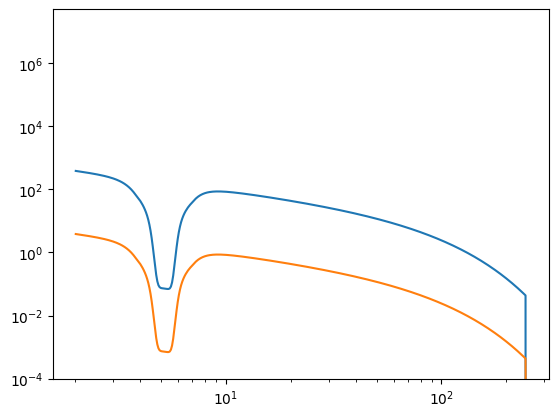

In [5]:
plt.loglog(sim.grid.r/c.au,sim.gas.Sigma)
plt.loglog(sim.grid.r/c.au,sim.dust.Sigma.sum(-1))
plt.ylim(1e-4)

In [6]:
list_t = []
list_ts = []
def updater_t(sim):
    list_t.append(sim.t.copy())
    list_ts.append(sim.t.prevstepsize)

sim.star.M.updater = updater_t

In [7]:
sim.writer.overwrite = True
#sim.t.cfl = 1e-2
sim.run()


tripodpy v1.0.0

Writing file data_duffle/data0000.hdf5
Writing dump file data_duffle/frame.dmp
Execution time: 0:00:14


In [8]:
sim.t/c.year

100000.0

In [9]:
import pandas as pd

df = pd.read_csv("gap_0002.outputdat", sep=r"\s+", header=None)

df2 = pd.read_csv("gap_0093.outputdat", sep=r"\s+", header=None)

In [10]:
df2[6][0]/c.year

np.float64(100019.37592163982)

In [11]:
sim.t/c.year

100000.0

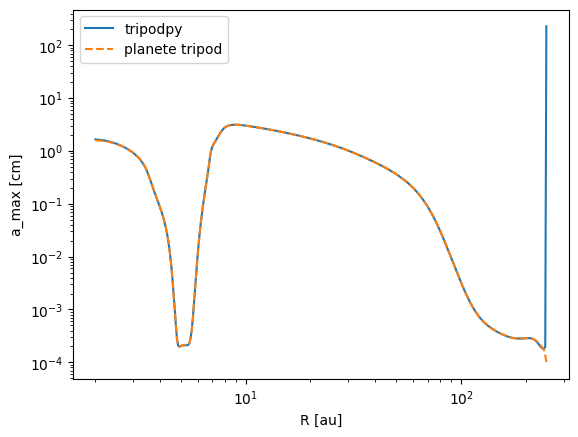

In [12]:
plt.figure()
plt.loglog(sim.grid.r/c.au,sim.dust.s.max,label="tripodpy")
#plt.loglog(df[1]/c.au,df[4],":")
plt.loglog(df2[1]/c.au,df2[4],"--",label="planete tripod")
plt.ylabel("a_max [cm]")
plt.xlabel("R [au]")
plt.legend()

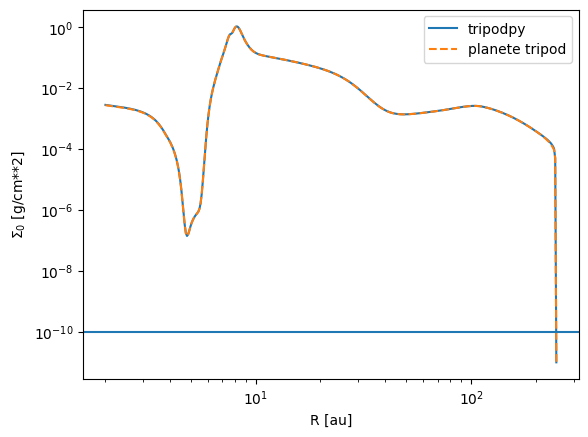

In [13]:
plt.figure()
plt.loglog(sim.grid.r/c.au,sim.dust.Sigma[:,0],label="tripodpy")
plt.loglog(df2[1]/c.au,df2[2],"--",label = "planete tripod")
#plt.loglog(df2[1]/c.au,df[2],"x--")
plt.axhline(1e-10)
plt.ylabel(r"$\Sigma_0$ [g/cm**2]")
plt.xlabel("R [au]")
#plt.ylim(1e-4)
plt.legend()

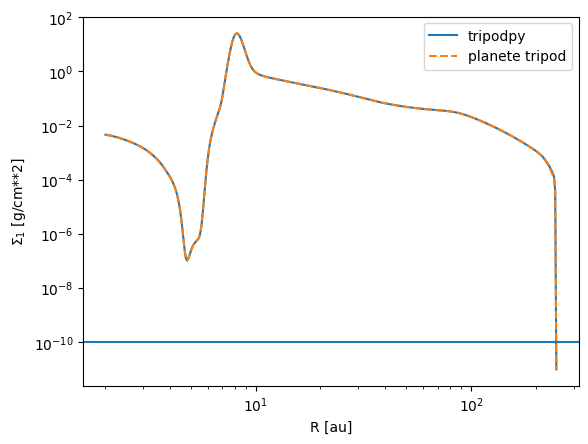

In [14]:
plt.figure()
plt.loglog(sim.grid.r/c.au,sim.dust.Sigma[:,1],label="tripodpy")
plt.loglog(df2[1]/c.au,df2[3],"--",label = "planete tripod")
#plt.loglog(df2[1]/c.au,df2[2],"--",label = "planete tripod")
plt.axhline(1e-10)
plt.ylabel(r"$\Sigma_1$ [g/cm**2]")
plt.xlabel("R [au]")
#plt.ylim(1e-4)
plt.legend()


(1, 500)

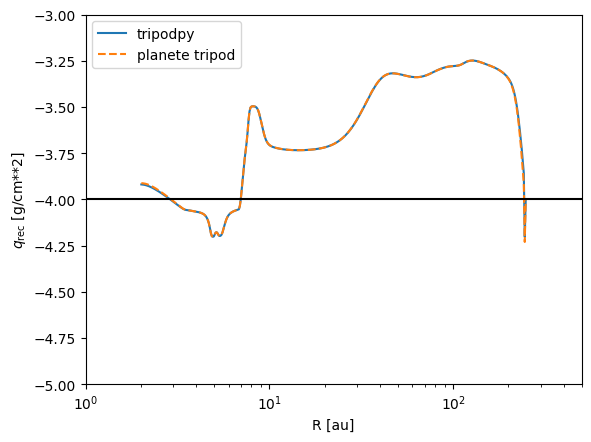

In [15]:
plt.figure()
plt.plot(sim.grid.r/c.au,sim.dust.qrec[:],label="tripodpy")
plt.plot(df2[1]/c.au,df2[5],"--",label = "planete tripod")
#plt.plot(df2[1]/c.au,df[5],"--",label = "planete tripod")
plt.ylabel(r"$q_{\rm rec}$ [g/cm**2]")
plt.xlabel("R [au]")
plt.legend()
plt.ylim(-5,-3)
plt.xscale("log")
plt.axhline(-4,color="k")
plt.xlim(1,500)

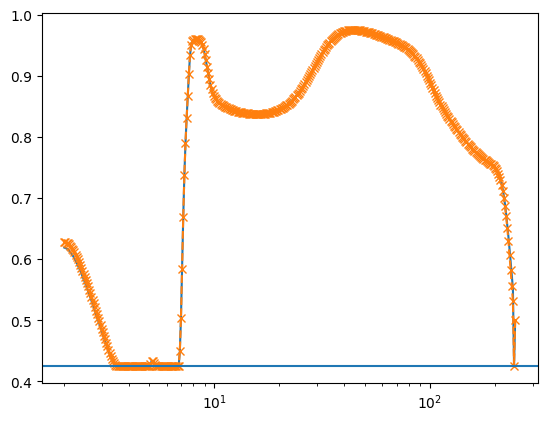

In [16]:
plt.figure()
plt.loglog(sim.grid.r/c.au,sim.dust.Sigma[:,1]/sim.dust.Sigma.sum(-1))
plt.loglog(df2[1]/c.au,df2[3]/(df2[3]+df2[2]),"x--")
#plt.loglog(df2[1]/c.au,df[3]/(df[3]+df[2]),"x--")
plt.yscale("linear")
plt.axhline(0.425)
#plt.loglog(df2[1]/c.au,df[2],"x--")

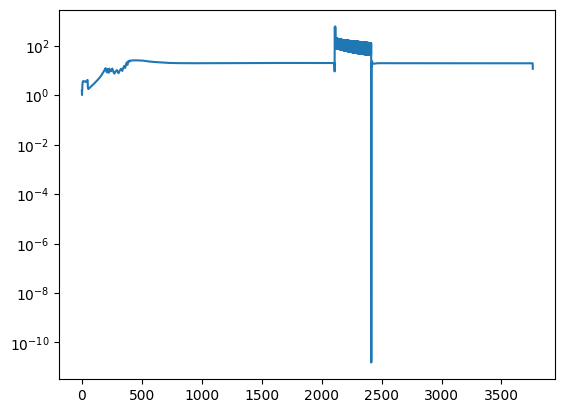

In [17]:
plt.figure()
plt.plot(np.array(list_ts)/c.year)
plt.yscale("log")

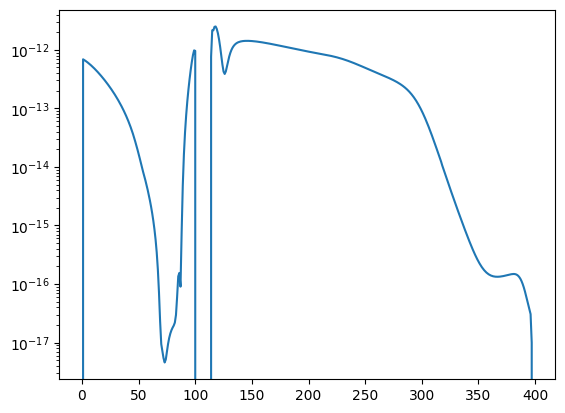

In [18]:
plt.plot(sim.dust.s.sdot_coag[:])
#plt.ylim(1e-3,1e3)
plt.yscale("log")

In [19]:
sim.dust.s.toc

Group (Characteristic particle sizes)
    - boundary: Group (boundary conditions of smax)
        - inner: Constant power law
        - outer: Constant power law
    - lim: Field (Limiting size for shrinking)
    - max: Field (Maximum particle size)
    - min: Field (Minimum particle size)
    - sdot_coag: Field (coagulation source term for amax [cm/s])
    - sdot_shrink: Field (shrinkage source term for amax [cm²/s])


In [20]:
sim.dust.v.driftmax

[-3.57092033e+003 -3.65713060e+003 -3.66626027e+003 -3.67845203e+003
 -3.69155241e+003 -3.70564259e+003 -3.72081196e+003 -3.73715914e+003
 -3.75479296e+003 -3.77383365e+003 -3.79441415e+003 -3.81668157e+003
 -3.84079883e+003 -3.86694654e+003 -3.89532503e+003 -3.92615671e+003
 -3.95968863e+003 -3.99619547e+003 -4.03598272e+003 -4.07939039e+003
 -4.12679708e+003 -4.17862449e+003 -4.23534249e+003 -4.29747467e+003
 -4.36560459e+003 -4.44038247e+003 -4.52253268e+003 -4.61286180e+003
 -4.71226728e+003 -4.82174677e+003 -4.94240795e+003 -5.07547871e+003
 -5.22231759e+003 -5.38442421e+003 -5.56344925e+003 -5.76120373e+003
 -5.97966681e+003 -6.22099172e+003 -6.48750893e+003 -6.78172581e+003
 -7.10632206e+003 -7.46414020e+003 -7.85817088e+003 -8.29153302e+003
 -8.76744993e+003 -9.28922346e+003 -9.86021025e+003 -1.04838062e+004
 -1.11634480e+004 -1.19026459e+004 -1.27050632e+004 -1.35746691e+004
 -1.41993532e+004 -1.37481968e+004 -1.33286729e+004 -1.41754374e+004
 -1.51329669e+004 -1.62342004e+004

(0.01, np.float64(2901.2162879836537))

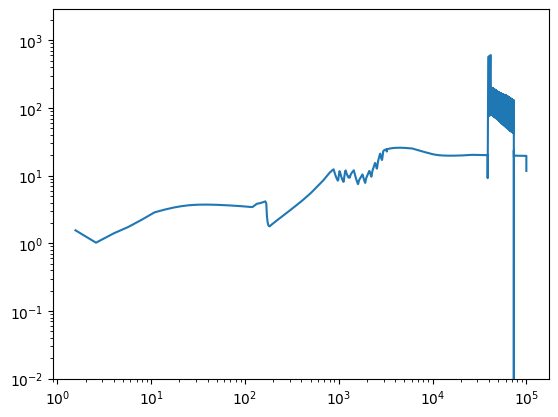

In [21]:
plt.figure()
plt.plot(np.array(list_t)/c.year,np.array(list_ts)/c.year)
plt.yscale("log")
plt.xscale("log")
plt.ylim(1e-2)

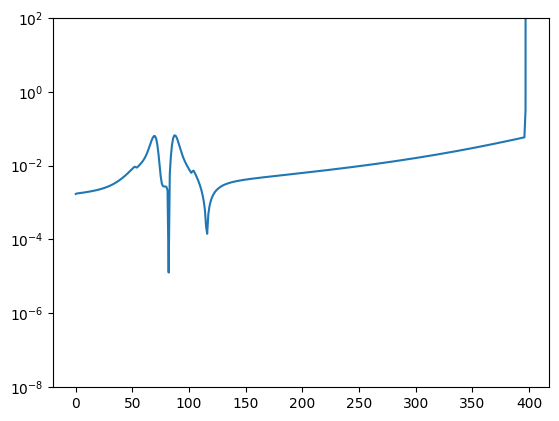

In [22]:
plt.plot(abs(sim.gas.eta))
plt.ylim(1e-8,1e2)
plt.yscale("log")


In [23]:
sim.gas.

SyntaxError: invalid syntax (916027320.py, line 1)